In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (roc_auc_score, recall_score, 
                             precision_score, f1_score,
                             roc_curve, confusion_matrix,
                             classification_report)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


In [2]:
# Load unscaled data for tree-based models (RF, XGBoost)
df_unscaled = pd.read_csv("../data/processed/feature_store_unscaled.csv")

# Load scaled data for Logistic Regression
df_scaled = pd.read_csv("../data/processed/feature_store.csv")

print(f"Unscaled shape: {df_unscaled.shape}")
print(f"Scaled shape: {df_scaled.shape}")
print(f"Target distribution:")
print(f"  Class 0: {(df_unscaled['readmitted_30']==0).sum():,}")
print(f"  Class 1: {(df_unscaled['readmitted_30']==1).sum():,}")

Unscaled shape: (180818, 33)
Scaled shape: (180818, 33)
Target distribution:
  Class 0: 90,409
  Class 1: 90,409


In [3]:
# Define feature groups
clinical_features = ['age', 'time_in_hospital', 'num_lab_procedures',
                     'num_procedures', 'num_medications', 'number_outpatient',
                     'number_emergency', 'number_inpatient', 'number_diagnoses',
                     'admission_type_id', 'discharge_disposition_id',
                     'admission_source_id', 'medical_specialty',
                     'diag_1', 'diag_2', 'diag_3']

sdoh_features = ['BPHIGH', 'CHECKUP', 'CHOLSCREEN',
                 'DEPRESSION', 'DIABETES', 'OBESITY']

medication_features = ['total_diabetes_meds', 'med_complexity_score',
                      'high_med_burden', 'on_insulin',
                      'multiple_med_changes']

risk_features = ['prior_utilization', 'high_prior_inpatient',
                 'emergency_admission', 'long_stay',
                 'high_diagnosis_burden']

all_features = clinical_features + sdoh_features + medication_features + risk_features

# Prepare datasets
# Clinical only (baseline)
X_clinical = df_unscaled[clinical_features]
X_clinical_scaled = df_scaled[clinical_features]

# Multi-source (all 32 features)
X_multi = df_unscaled[all_features]
X_multi_scaled = df_scaled[all_features]

# Target
y = df_unscaled['readmitted_30']

print(f"Clinical features: {X_clinical.shape[1]}")
print(f"Multi-source features: {X_multi.shape[1]}")
print(f"Target samples: {len(y):,}")

Clinical features: 16
Multi-source features: 32
Target samples: 180,818


In [5]:
## Train Logistic Regression (baseline)
# Model 1 - Logistic Regression (clinical only - baseline)
print("Training Logistic Regression (clinical only)")

lr_model = LogisticRegression(max_iter=1000, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_scores = cross_validate(
    lr_model, X_clinical_scaled, y,
    cv=cv,
    scoring=['roc_auc', 'recall', 'precision', 'f1'],
    return_train_score=False
)

print("Logistic Regression done!")
print(f"Results:")
print(f"  ROC-AUC: {lr_scores['test_roc_auc'].mean():.4f} (+/- {lr_scores['test_roc_auc'].std():.4f})")
print(f"  Recall: {lr_scores['test_recall'].mean():.4f} (+/- {lr_scores['test_recall'].std():.4f})")
print(f"  Precision: {lr_scores['test_precision'].mean():.4f} (+/- {lr_scores['test_precision'].std():.4f})")
print(f"  F1: {lr_scores['test_f1'].mean():.4f} (+/- {lr_scores['test_f1'].std():.4f})")

Training Logistic Regression (clinical only)
Logistic Regression done!
Results:
  ROC-AUC: 0.6453 (+/- 0.0015)
  Recall: 0.6195 (+/- 0.0021)
  Precision: 0.6048 (+/- 0.0022)
  F1: 0.6121 (+/- 0.0004)


In [ ]:
## Train Random Forest
# Model 2 - Random Forest (clinical only)
print("Training Random Forest (clinical only)")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_scores = cross_validate(
    rf_model, X_clinical, y,
    cv=cv,
    scoring=['roc_auc', 'recall', 'precision', 'f1'],
    return_train_score=False
)

print("Random Forest done!")
print(f"Results:")
print(f"  ROC-AUC: {rf_scores['test_roc_auc'].mean():.4f} (+/- {rf_scores['test_roc_auc'].std():.4f})")
print(f"  Recall: {rf_scores['test_recall'].mean():.4f} (+/- {rf_scores['test_recall'].std():.4f})")
print(f"  Precision: {rf_scores['test_precision'].mean():.4f} (+/- {rf_scores['test_precision'].std():.4f})")
print(f"  F1: {rf_scores['test_f1'].mean():.4f} (+/- {rf_scores['test_f1'].std():.4f})")

Training Random Forest (clinical only)
Random Forest done!
Results:
  ROC-AUC: 0.9463 (+/- 0.0013)
  Recall: 0.8778 (+/- 0.0016)
  Precision: 0.8794 (+/- 0.0038)
  F1: 0.8786 (+/- 0.0023)


In [8]:
## Train XGBoost (clinical only)
# Model 3 - XGBoost (clinical only)
print("Training XGBoost (clinical only)")

xgb_clinical = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_clinical_scores = cross_validate(
    xgb_clinical, X_clinical, y,
    cv=cv,
    scoring=['roc_auc', 'recall', 'precision', 'f1'],
    return_train_score=False
)

print("XGBoost (clinical only) done!")
print(f"Results:")
print(f"  ROC-AUC: {xgb_clinical_scores['test_roc_auc'].mean():.4f} (+/- {xgb_clinical_scores['test_roc_auc'].std():.4f})")
print(f"  Recall: {xgb_clinical_scores['test_recall'].mean():.4f} (+/- {xgb_clinical_scores['test_recall'].std():.4f})")
print(f"  Precision: {xgb_clinical_scores['test_precision'].mean():.4f} (+/- {xgb_clinical_scores['test_precision'].std():.4f})")
print(f"  F1: {xgb_clinical_scores['test_f1'].mean():.4f} (+/- {xgb_clinical_scores['test_f1'].std():.4f})")

Training XGBoost (clinical only)
XGBoost (clinical only) done!
Results:
  ROC-AUC: 0.8715 (+/- 0.0027)
  Recall: 0.7585 (+/- 0.0017)
  Precision: 0.8084 (+/- 0.0048)
  F1: 0.7826 (+/- 0.0029)


In [10]:
## Train XGBoost (multi-source)
# Model 4 - XGBoost (multi-source - all 32 features)
print("Training XGBoost (multi-source)")

xgb_multi = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_multi_scores = cross_validate(
    xgb_multi, X_multi, y,
    cv=cv,
    scoring=['roc_auc', 'recall', 'precision', 'f1'],
    return_train_score=False
)

print("XGBoost (multi-source) done!")
print(f"Results:")
print(f"  ROC-AUC: {xgb_multi_scores['test_roc_auc'].mean():.4f} (+/- {xgb_multi_scores['test_roc_auc'].std():.4f})")
print(f"  Recall: {xgb_multi_scores['test_recall'].mean():.4f} (+/- {xgb_multi_scores['test_recall'].std():.4f})")
print(f"  Precision: {xgb_multi_scores['test_precision'].mean():.4f} (+/- {xgb_multi_scores['test_precision'].std():.4f})")
print(f"  F1: {xgb_multi_scores['test_f1'].mean():.4f} (+/- {xgb_multi_scores['test_f1'].std():.4f})")

Training XGBoost (multi-source)
XGBoost (multi-source) done!
Results:
  ROC-AUC: 0.9490 (+/- 0.0007)
  Recall: 0.8425 (+/- 0.0025)
  Precision: 0.9740 (+/- 0.0013)
  F1: 0.9035 (+/- 0.0010)


In [12]:
## Model comparison table
# Build model comparison table
results = {
    'Model': [
        'Logistic Regression (clinical)',
        'Random Forest (clinical)',
        'XGBoost (clinical only)',
        'XGBoost (multi-source)'
    ],
    'ROC-AUC': [
        lr_scores['test_roc_auc'].mean(),
        rf_scores['test_roc_auc'].mean(),
        xgb_clinical_scores['test_roc_auc'].mean(),
        xgb_multi_scores['test_roc_auc'].mean()
    ],
    'Recall': [
        lr_scores['test_recall'].mean(),
        rf_scores['test_recall'].mean(),
        xgb_clinical_scores['test_recall'].mean(),
        xgb_multi_scores['test_recall'].mean()
    ],
    'Precision': [
        lr_scores['test_precision'].mean(),
        rf_scores['test_precision'].mean(),
        xgb_clinical_scores['test_precision'].mean(),
        xgb_multi_scores['test_precision'].mean()
    ],
    'F1': [
        lr_scores['test_f1'].mean(),
        rf_scores['test_f1'].mean(),
        xgb_clinical_scores['test_f1'].mean(),
        xgb_multi_scores['test_f1'].mean()
    ]
}

df_results = pd.DataFrame(results)
df_results = df_results.round(4)

print("=" * 70)
print("MODEL COMPARISON TABLE")
print("=" * 70)
print(df_results.to_string(index=False))
print("=" * 70)
print(f"Best Model: XGBoost (multi-source)")
print(f"  ROC-AUC improvement over baseline: +{(xgb_multi_scores['test_roc_auc'].mean() - lr_scores['test_roc_auc'].mean()):.4f}")
print(f"  F1 improvement over baseline: +{(xgb_multi_scores['test_f1'].mean() - lr_scores['test_f1'].mean()):.4f}")

MODEL COMPARISON TABLE
                         Model  ROC-AUC  Recall  Precision     F1
Logistic Regression (clinical)   0.6453  0.6195     0.6048 0.6121
      Random Forest (clinical)   0.9463  0.8778     0.8794 0.8786
       XGBoost (clinical only)   0.8715  0.7585     0.8084 0.7826
        XGBoost (multi-source)   0.9490  0.8425     0.9740 0.9035
Best Model: XGBoost (multi-source)
  ROC-AUC improvement over baseline: +0.3037
  F1 improvement over baseline: +0.2914


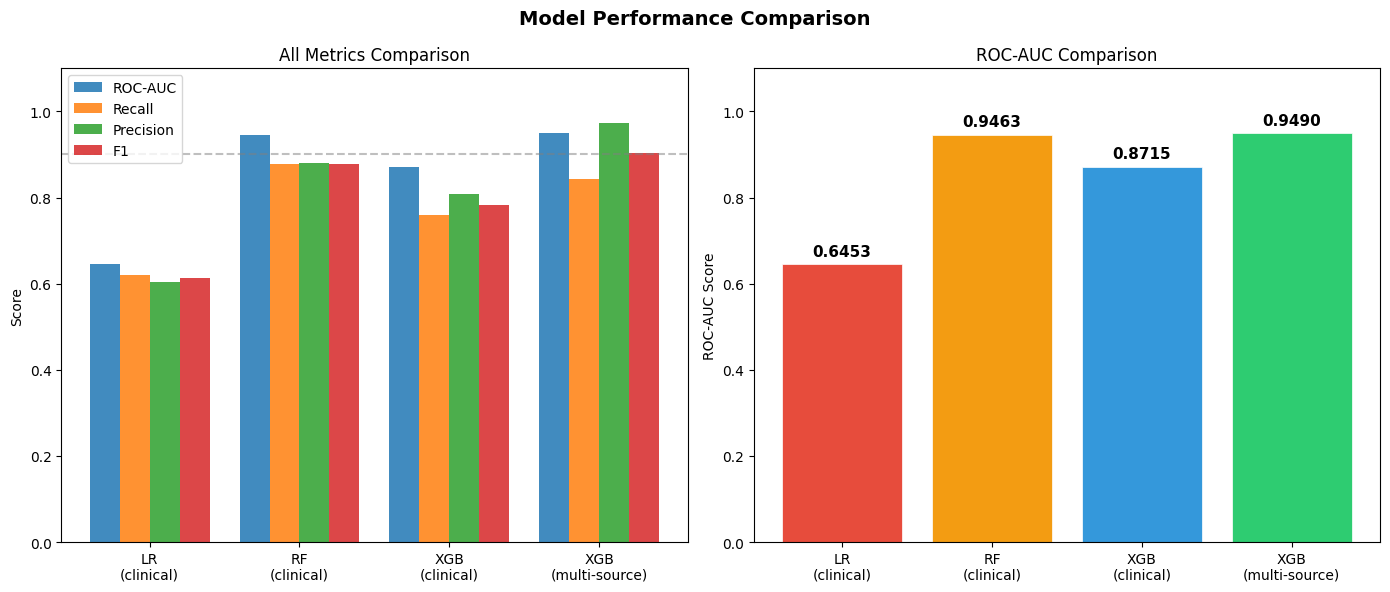

Plot saved!


In [13]:
# Plot model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models = ['LR\n(clinical)', 'RF\n(clinical)', 'XGB\n(clinical)', 'XGB\n(multi-source)']
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

metrics = ['ROC-AUC', 'Recall', 'Precision', 'F1']
values = [
    [0.6453, 0.9463, 0.8715, 0.9490],
    [0.6195, 0.8778, 0.7585, 0.8425],
    [0.6048, 0.8794, 0.8084, 0.9740],
    [0.6121, 0.8786, 0.7826, 0.9035]
]

# Bar chart for all metrics
x = np.arange(len(models))
width = 0.2

for i, (metric, vals) in enumerate(zip(metrics, values)):
    axes[0].bar(x + i*width, vals, width, 
                label=metric, alpha=0.85)

axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('All Metrics Comparison')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].axhline(y=0.9, color='gray', linestyle='--', alpha=0.5)

# ROC-AUC focused chart
roc_values = [0.6453, 0.9463, 0.8715, 0.9490]
bars = axes[1].bar(models, roc_values, color=colors, 
                   edgecolor='white', linewidth=0.5)
axes[1].set_title('ROC-AUC Comparison')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim(0, 1.1)
for bar, val in zip(bars, roc_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, 
                val + 0.02, f'{val:.4f}',
                ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Model Performance Comparison', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../dashboard/model_comparison.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [15]:
# Train and save the best model
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42, stratify=y
)

# Train final best model on full training set
print("Training final best model")

best_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

best_model.fit(X_train, y_train)

# Evaluate on test set
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Best model trained!")
print(f"Test Set Results:")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred):.4f}")

Training final best model
Best model trained!
Test Set Results:
  ROC-AUC:   0.9473
  Recall:    0.8396
  Precision: 0.9743
  F1:        0.9019


In [16]:
# Save best model
joblib.dump(best_model, "../models/best_xgb_model.pkl")
print("Best model saved!")

# Export model comparison for Power BI
df_results.to_csv("../dashboard/model_comparison.csv", index=False)
print("Model comparison CSV saved!")

# Export patient risk scores for Power BI
X_test_copy = X_test.copy()
X_test_copy['actual'] = y_test.values
X_test_copy['risk_score'] = y_prob
X_test_copy['predicted'] = y_pred

# Add risk tier
def risk_tier(score):
    if score < 0.25:
        return 'Low'
    elif score < 0.60:
        return 'Medium'
    else:
        return 'High'

X_test_copy['risk_tier'] = X_test_copy['risk_score'].apply(risk_tier)

# Save risk scores
X_test_copy[['risk_score', 'risk_tier', 'actual', 'predicted',
             'age', 'time_in_hospital', 'num_medications',
             'number_diagnoses', 'number_inpatient',
             'OBESITY', 'DIABETES', 'DEPRESSION']].to_csv(
    "../dashboard/patient_risk_scores.csv", index=False)

print("Patient risk scores saved!")
print(f"Risk tier distribution:")
print(X_test_copy['risk_tier'].value_counts())

Best model saved!
Model comparison CSV saved!
Patient risk scores saved!
Risk tier distribution:
risk_tier
Low       14925
High      14668
Medium     6571
Name: count, dtype: int64


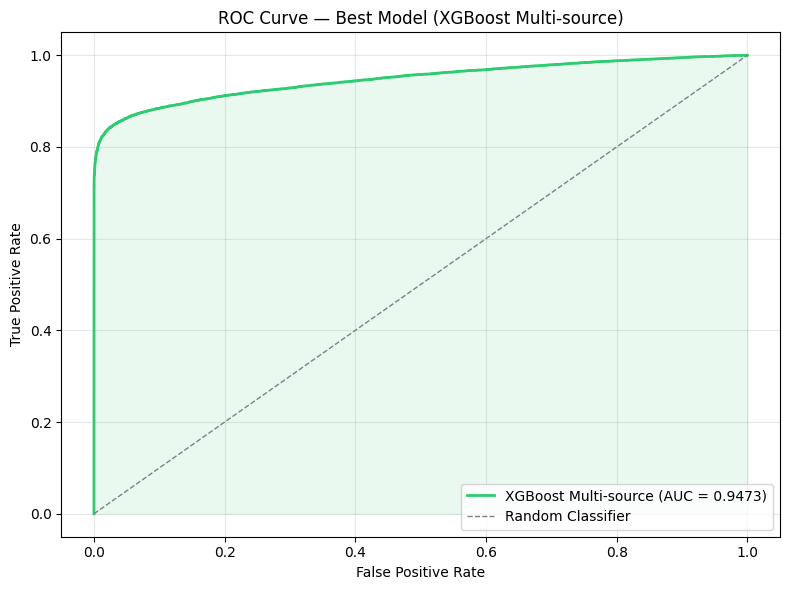

ROC curve saved!


In [17]:
# Plot ROC curve for best model
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2ecc71', linewidth=2,
         label=f'XGBoost Multi-source (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', 
         linewidth=1, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#2ecc71')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Best Model (XGBoost Multi-source)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../dashboard/roc_curve.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print("ROC curve saved!")

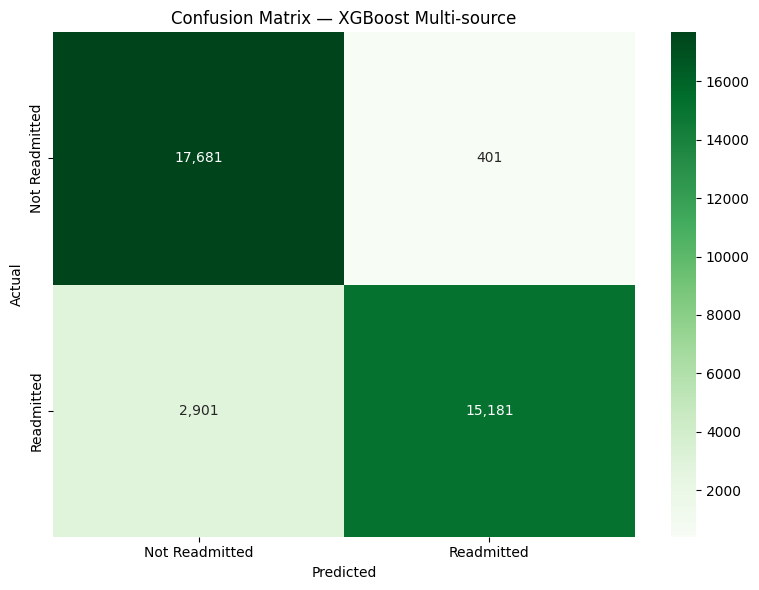

Confusion matrix saved!


In [18]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=',', cmap='Greens',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title('Confusion Matrix — XGBoost Multi-source')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig("../dashboard/confusion_matrix.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")

In [20]:
# Verify all saved files
import os

print("models/")
for f in sorted(os.listdir("../models/")):
    size = os.path.getsize(f"../models/{f}")
    print(f"  {f} — {size/1024:.1f} KB")

print("dashboard/")
for f in sorted(os.listdir("../dashboard/")):
    size = os.path.getsize(f"../dashboard/{f}")
    print(f"  {f} — {size/1024:.1f} KB")

models/
  best_xgb_model.pkl — 375.2 KB
  scaler.pkl — 2.1 KB
dashboard/
  age_analysis.png — 68.5 KB
  clinical_features.png — 149.4 KB
  confusion_matrix.png — 44.8 KB
  correlation_heatmap.png — 180.7 KB
  diagnosis_analysis.png — 96.7 KB
  inpatient_analysis.png — 82.1 KB
  model_comparison.csv — 0.2 KB
  model_comparison.png — 57.5 KB
  patient_risk_scores.csv — 2233.3 KB
  roc_curve.png — 65.7 KB
  sdoh_features.png — 173.4 KB
  target_distribution.png — 73.2 KB
